# Lecture 18

# Exploratory Data Analysis with Seaborn

## Week 7 Monday

## Miles Chen, PhD

References:
+ https://seaborn.pydata.org/tutorial/function_overview.html
+ https://seaborn.pydata.org/api.html

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
sns.__version__

'0.13.2'

# Seaborn is for visual exploration

The primary purpose of seaborn is to make plots and visualize data quickly and beautifully.

Seaborn is heavily designed around **Tidy Data** (long-form data). 

This means it works best when:

1. Each column is a variable.
2. Each row is an observation.

If your data is in a "wide" format (like a correlation matrix or pivot table), you may need to reshape it using pandas (e.g., `pd.melt()`) before Seaborn can plot it effectively.

## The Most Important Seaborn Concept: Figure-Level vs. Axes-Level

In Lecture 17, we learned about Matplotlib's Object-Oriented interface (`fig, ax = plt.subplots()`). Seaborn functions fall into two categories:

1. **Axes-level functions** 
   -  `sns.histplot`
   -  `sns.boxplot`
   -  `sns.scatterplot`
   - These draw onto a specific Matplotlib `Axes`. You can place them inside a complex `plt.subplots()` grid using the `ax=` argument.

2. **Figure-level functions** 
   - `sns.displot`
   - `sns.catplot`
   - `sns.relplot`
   - These generate their *own* Matplotlib `Figure` from scratch. They are incredibly powerful for creating grids of plots automatically (faceting), but they cannot easily be dropped into an existing `plt.subplots()` layout.

**We will focus primarily on the Figure-Level "Big Three":**

- `sns.displot()` for distributions
- `sns.catplot()` for categorical data
- `sns.relplot()` for relational data (scatter/line)

In [3]:
penguins = sns.load_dataset("penguins")

In [4]:
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


# Univariate exploration: sns.displot() (figure-level plot)

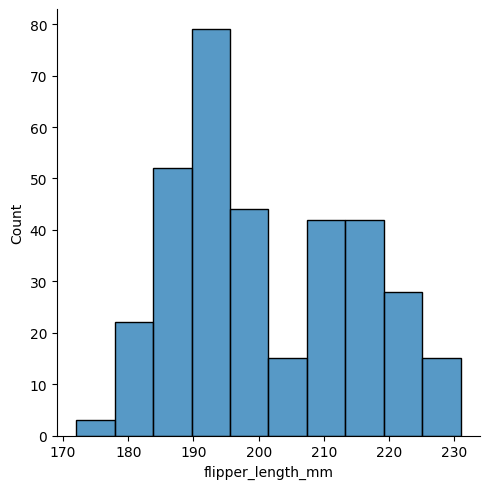

In [5]:
sns.displot(data = penguins, x = "flipper_length_mm")

# Note: In Jupyter, simply having the seaborn object on the last line 
# automatically displays the plot. plt.show() is good practice for scripts,
# but often optional in interactive notebooks.

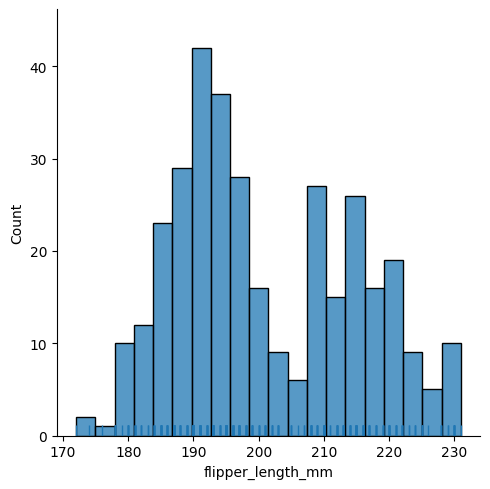

In [6]:
sns.displot(data = penguins, x = "flipper_length_mm", bins = 20, rug=True)
plt.show()

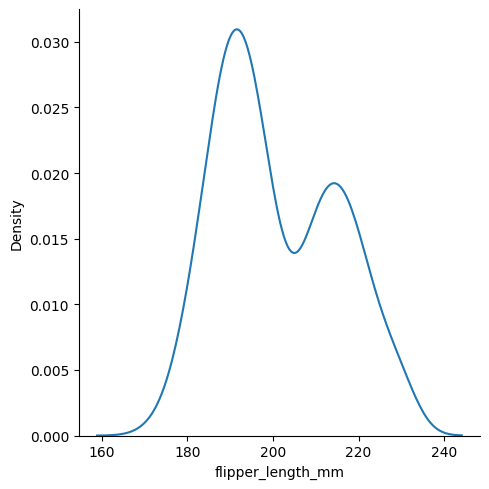

In [7]:
sns.displot(data = penguins, x = "flipper_length_mm", kind = "kde")
plt.show()
# By changing kind="kde", the figure-level function swaps the underlying axes-level plot.

In [ ]:
sns.displot(data=penguins, x="flipper_length_mm", hue="species", kind="kde")
plt.show()

### Customizing Figure-Level Plots
Because figure-level plots return a `FacetGrid` object (not a standard Axes object), setting titles requires a slightly different approach.

In [ ]:
g = sns.displot(data=penguins, x="flipper_length_mm", hue="species", multiple="stack")

# We access the underlying figure to set a super title
g.figure.suptitle("Distribution of Flipper Lengths by Species", y=1.05) # y=1.05 prevents overlap
plt.show()

# Bivariate exploration

In [ ]:
sns.displot(data=penguins, x="flipper_length_mm", y="bill_length_mm", hue="species", kind="kde")
plt.show()

In [ ]:
sns.jointplot(data=penguins, x="flipper_length_mm", y="bill_length_mm", hue = "species")
plt.show()

## Pair-wise plots for multiple numeric data variables

In [ ]:
iris = sns.load_dataset("iris")
sns.pairplot(iris, hue="species") # figure-level plot
plt.show()

# Categorical Plots: sns.catplot()

Just as `displot` handles all distribution types, `catplot` handles all categorical types (stripplots, boxplots, violins, bar charts) simply by changing the `kind` parameter.

In [ ]:
tips = sns.load_dataset("tips")
tips.head()
# tips data, contains numeric vars: total_bill, tip, size
# categorical vars: sex, smoker, day, time

In [ ]:
# Default is kind="strip" (a scatterplot where one axis is categorical)
sns.catplot(data=tips, x="day", y="total_bill", jitter=True) # figure-level plot
plt.show()

In [ ]:
sns.catplot(data=tips, x="day", y="total_bill", kind="swarm")
plt.show()
# swarmplots are like symmetric dotplots

In [ ]:
sns.catplot(data=tips, x="day", y="total_bill", hue="sex", kind="box") 
plt.show()
# Notice how easily we swap to a boxplot!

In [ ]:
sns.catplot(data=tips, x="day", y="total_bill", hue="sex", kind="violin", split=True)
plt.show()

In [ ]:
# Bar charts (count plots) for data that is only categorical
sns.catplot(data=tips, x="sex", hue='time', kind="count") 
plt.show()

## Faceting: The power of Figure-Level functions

The primary reason we use `displot`, `catplot`, and `relplot` is their ability to instantly generate grids of plots based on categorical variables using `row=` and `col=`.

In [ ]:
sns.displot(data=penguins, x="flipper_length_mm", hue="species", row="sex", col="island", kind="kde")
plt.show()

In [ ]:
sns.catplot(data=tips, x="day", y="total_bill", hue="sex", col="time", kind="box")
plt.show()

### Advanced: FacetGrid

Under the hood, figure-level plots are using `sns.FacetGrid`. While you usually don't need to call it directly anymore, you can use it to map completely custom Matplotlib functions across a grid.

In [ ]:
g = sns.FacetGrid(tips, row='time', col='sex', margin_titles=True) 
g.map(plt.hist, "total_bill", density=True, bins=10)
plt.show()

# Fitting basic statistical models

In [ ]:
# sns.lmplot is the figure-level equivalent for linear models
sns.lmplot(data=tips, x="total_bill", y="tip", hue="smoker", col="time")
plt.show()

In [ ]:
# If you just want the scatterplot without the regression line, use relplot!
sns.relplot(data=tips, x="total_bill", y="tip", hue="smoker", col="time")
plt.show()

In [ ]:
# sns.residplot is an axes-level function for checking model residuals
sns.residplot(data=tips, x="total_bill", y="tip")
plt.show()